# <font size = 5>Setting up</font>

In [1904]:
# imports and suppress warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import sys
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter
import pandas as pd
from qutip import *
import krotov
import scipy.constants
import pickle
from tkinter import filedialog # for prompting user to set analysis folder
import glob
# import lyse
import h5py
from pathlib import PureWindowsPath, PurePosixPath
from tqdm import tqdm
from joblib import Parallel, delayed
import numba
from sympy.physics.wigner import wigner_3j, wigner_6j
from lmfit import Model, Parameters
from lmfit.models import LinearModel
from PIL import Image
from scipy.special import jn, jn_zeros
from scipy.stats import halfnorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from numpy.fft import fft2, fftshift, ifftshift, ifft2, fft, fftfreq

# suppress warnings: do at your own risk!
import warnings
warnings.filterwarnings("ignore")

In [2]:
# physics constants
ABSORPTION_LIMIT = 5.0
SPECIAL_CHARACTERS = "!@#$%^&*()-+?_=,<>/"

# physics constants
hbar = 1.05457182*10**(-34) # Js
c = 299792458 # m/s
h_planck = hbar*2*np.pi  # Js
me = 9.1093837015e-31    # electron mass
mn = 1.67493e-27         # neutron mass
eC = 1.60218e-19         # electric charge
muB = eC*hbar/(2*me)     # Bohr magneton
muB_cm1_G = muB / (100*c*h_planck*1e4) # Bohr magneton in units of cm-1 per Gauss
a0 = 5.2917720859e-11    # Bohr radius
muN = scipy.constants.physical_constants['nuclear magneton'][0]
eps0 = scipy.constants.epsilon_0
gS = 2.0023193043622
DebyeSI = 3.33564e-30
kB = 1.380649e-23

# Lithium constants
mLi6 = 9.9883414*10**(-27) # kg
Li6D2Gamma = 5.8724e6 # Hz Note that this is NOT angular freq
Li6D2lambda0 = 670.977338*10**(-9) # meters
Li6D2sigma0 = 3*(Li6D2lambda0)**2/(2*np.pi)
Li6Ahf_s12 = 152.1368407e6  # This is NOT angular freq
Li6Bhf_s12 = 0
Li6Ahf_p12 = 17.386e6 # Hz
Li6Bhf_p12 = 0
Li6Ahf_p32 = -1.155e6 # Hz
Li6Bhf_p32 = -0.10e6 # Hz
Li6I = 1
Li6gI = -0.0004476540

# Sodium-23 constants
mNa23 = 0.38175403519e-25 # kg
Na23D2Gamma = 9.794646e6 # Hz
Na23D2lambda0 = 589.158326415e-9 # meters
Na23D2sigma0 = 3*(Na23D2lambda0)**2/(2*np.pi)
Na23Ahf_s12 = 885.8130644050e6 # Hz
Na23Bhf_s12 = 0e6 # Hz
Na23Ahf_p12 = 94.4413e6 # Hz
Na23Bhf_p12 = 0e6 # Hz
Na23Ahf_p32 = 18.53415e6 # Hz
Na23Bhf_p32 = 2.72430e6 # Hz
Na23I = 3/2
Na23gI = -0.0008046108080

# Potassium-40 constants
mK40 = 39.9639984821*1.6605402e-27 # kg 
K40D2Gamma = 6.03511 # MHz
K40D2lambda0 = 766.700674872173e-9 # meters
K40D2sigma0 = 3*(K40D2lambda0)**2/(2*np.pi)
K40Ahf_s12 = -285.730824e6 # Hz
K40Bhf_s12 = 0
K40Ahf_p12 = -34.52325e6 # Hz
K40Bhf_p12 = 0
K40Ahf_p32 = -7.58510e6 # Hz
K40Bhf_p32 = -3.44590e6 # Hz
K40I = 4
K40gI = 0.00017649034

# NaK constants:
mK41 = 6.80187059497004e-26 # kg
mK40 = 6.63617749148248e-26 # kg
mK39 = 6.47007514485677e-26 # kg
u = 1.660538782e-27  # kg
Eh = 4.35974394e-18 
RKRcst = hbar/np.sqrt(2*u) * (10**10) * np.sqrt(1/(100 * c * hbar * 2*np.pi)) 
muNa39K = (mNa23 * mK39)/(mNa23 + mK39) * 1/u # atomic units
muNa40K = (mNa23 * mK40)/(mNa23 + mK40) * 1/u # atomic units 
muNa41K = (mNa23 * mK41)/(mNa23 + mK41) * 1/u # atomic units

# <font size = 5>Microscope objective characterization: magnification</font>

Magnification: 
51.74361658232628


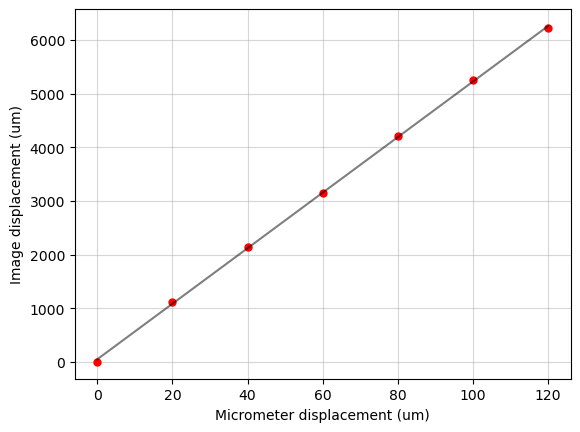

In [38]:
# magnification measurement

micrometer_screw_position = np.array([5.86, 5.88, 5.90, 5.92, 5.94, 5.96, 5.98]) # mm
x_loc = np.array([366, 271, 190, 115, 30, -42, -122]) # um
y_loc = np.array([2232, 1114, 100, -906, -1959, -2995, -3972]) # um

micrometer_screw_displacement = 1000 * (micrometer_screw_position - micrometer_screw_position[0]) # um
x_dis = x_loc - x_loc[0]
y_dis = y_loc - y_loc[0]
total_dis = np.sqrt(x_dis**2 + y_dis**2)

# fit line to model:
model = LinearModel()
params = model.make_params()
out = model.fit(total_dis, params, x = micrometer_screw_displacement)

print('Magnification: ')
print(out.params['slope'].value)

plt.plot(micrometer_screw_displacement, total_dis, '.', color = 'red', markersize = 10)
plt.xlabel('Micrometer displacement (um)')
plt.ylabel('Image displacement (um)')
plt.plot(micrometer_screw_displacement, out.best_fit, '-', label='best fit', color = 'black', alpha = 0.5)
plt.grid(alpha=0.5)
plt.show()


# <font size = 5>Microscope objective characterization: PSF</font>

In [1770]:
# helper functions
def profile_gaussian_with_offset(x, amplitude, offset, Sx, Sy, x_center, y_center, theta):
    xx, yy = x
    x_prime =  np.cos(theta) * (xx-x_center) + np.sin(theta)*(yy-y_center)
    y_prime = -np.sin(theta) * (xx-x_center) + np.cos(theta)*(yy-y_center)
    profile_gaussian =  amplitude*np.exp(-x_prime**2/(2*Sx**2))*np.exp(-y_prime**2/(2*Sy**2)) + offset
    return profile_gaussian.ravel()

def find_center(data, show_fit = True):
    data = np.nan_to_num(data, nan = np.inf)
    y_size = np.shape(data)[0]
    x_size = np.shape(data)[1]
    x = np.linspace(0, x_size - 1, x_size)
    y = np.linspace(0, y_size - 1, y_size)
    X,Y = np.meshgrid(x,y)
    # generate initial guess
    amplitude_guess = np.max(data)
    offset_guess = 0
    Sx_guess = 5
    Sy_guess = 5
    x_center_guess = x_size//2
    y_center_guess = y_size//2
    theta_guess = 0
    # generate fit model:
    model = Model(profile_gaussian_with_offset)
    params = model.make_params(amplitude=amplitude_guess,
                               offset=offset_guess,
                               Sx=Sx_guess,
                               Sy = Sy_guess,
                               x_center = x_center_guess,
                               y_center = y_center_guess,
                               theta = theta_guess)
    lmfit_result = model.fit(data.ravel(), params, x= np.array((X, Y)), weights = None)
    report = lmfit_result.fit_report()
    # print(report)
    popt = lmfit_result.params
    # compute residuals
    data_fitted = profile_gaussian_with_offset((X,Y),
                                               amplitude = popt['amplitude'].value,
                                               offset = popt['offset'].value,
                                               Sx = popt['Sx'].value,
                                               Sy = popt['Sy'].value,
                                               x_center = popt['x_center'].value,
                                               y_center = popt['y_center'].value,
                                               theta = popt['theta'].value)
    data_fitted = data_fitted.reshape(y_size,x_size)
    residuals = data - data_fitted
    if show_fit:
        fig, ax = plt.subplots(1,4, figsize=(10,3))
        ax[0].contour(X, Y, data_fitted, 3, colors = 'white', linewidth = 0.1, alpha = 0.75)
        ax[0].pcolor(X, Y, data, cmap = 'plasma')
        ax[0].set_title(f'Sx = {popt["Sx"].value:.1f} px\n Sy = {popt["Sy"].value:.1f} px', fontsize = 12)
        ax[1].hist(residuals.ravel(), bins='auto', edgecolor='black', linewidth=0.1)
        ax[1].set_title(f'Histogram of residuals', fontsize = 12)
        ax[2].plot(x, data_fitted[y_size//2,:])
        ax[2].plot(x, data[y_size//2,:])
        ax[2].set_title('Cut along X at Y-center')
        ax[3].plot(y, data_fitted[:,x_size//2])
        ax[3].plot(y, data[:,x_size//2])
        ax[3].set_title('Cut along Y at X-center')
        plt.tight_layout()
        plt.show()
    return popt["x_center"].value, popt["y_center"].value

def radial_profile(data, center,  camera_magnification, imaging_magnification):
    y, x = np.indices((data.shape))
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    return r.ravel() * camera_magnification * 1000 / imaging_magnification, data.ravel()

def radial_profile_with_binning(data, center, bins, camera_magnification, imaging_magnification):
    y, x = np.indices((data.shape))
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    # now sort and bin
    s = np.argsort(r.ravel())
    sorted_r = r.ravel()[s] * camera_magnification * 1000 / imaging_magnification
    sorted_data = data.ravel()[s] # sorted by r
    r_binned_data, edges, _ = scipy.stats.binned_statistic(sorted_r, sorted_data, 'mean', bins=bins)
    r_binned = edges[:-1]
    return r_binned, r_binned_data/max(r_binned_data)

def ideal_psf(r, NA = 0.7, lam = 589):
    R = 0.61 * lam / NA # radius of first zero, lam in nm
    Rz = 1.2196698912665045
    u = np.pi * r / (R/Rz) # r in nm
    return (2 * jn(1, u) / u)**2

In [1764]:
# wavefront expansion Zernike coef fit
def Zernike_cartesian(x, Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44):
    u,v = x
    r = np.sqrt(u**2 + v**2) 
    ZW = 0
    ZW += Z00  * 1 # piston, just constant phase, no need to add
    ZW += Z11  * 2*u # X-tilt
    ZW += Zm11 * 2*v # Y-tilt
    ZW += Z02  * np.sqrt(3)*(2*r**2-1) # defocus
    ZW += Zm22 * 2*np.sqrt(6)*u*v # oblique astigmatism
    ZW += Z22  * np.sqrt(6)*(u**2-v**2) # vertical astigmatism
    ZW += Zm13 * np.sqrt(8)*v*(3*r**2-2) # vertical coma
    ZW += Z13  * np.sqrt(8)*u*(3*r**2-2) # horizontal coma
    ZW += Zm33 * np.sqrt(8)*v*(3*u**2-v**2) # vertical trefoil
    ZW += Z33  * np.sqrt(8)*u*(u**2-3*v**2) # oblique trefoil
    ZW += Zm44 * 4*np.sqrt(10)*u*v*(u**2-v**2) # oblique quadrafoil 
    ZW += Zm24 * 2*np.sqrt(10)*u*v*(4*r**2-3) # oblique secondary astigmatism
    ZW += Z04  * np.sqrt(5)*(6*r**4-6*r**2+1)  # primary spherical
    ZW += Z24  * np.sqrt(10)*(u**2-v**2)*(4*r**2-3) # vertical secondary astigmatism
    ZW += Z44  * np.sqrt(10)*(r**4-8*u**2*v**2) # vertical quadrafoil 
    '''
    Z16 =  Z[15] * np.sqrt(12)*x*(10*r**4-12*r**2+3)
    Z17 =  Z[16] * np.sqrt(12)*y*(10*r**4-12*r**2+3)
    Z18 =  Z[17] * np.sqrt(12)*x*(x**2-3*y**2)*(5*r**2-4)
    Z19 =  Z[18] * np.sqrt(12)*y*(3*x**2-y**2)*(5*r**2-4)
    Z20 =  Z[19] * np.sqrt(12)*x*(16*x**4-20*x**2*r**2+5*r**4)
    Z21 =  Z[20] * np.sqrt(12)*y*(16*y**4-20*y**2*r**2+5*r**4)
    Z22 =  Z[21] * np.sqrt(7)*(20*r**6-30*r**4+12*r**2-1)
    Z23 =  Z[22] * 2*np.sqrt(14)*x*y*(15*r**4-20*r**2+6)
    Z24 =  Z[23] * np.sqrt(14)*(x**2-y**2)*(15*r**4-20*r**2+6)
    Z25 =  Z[24] * 4*np.sqrt(14)*x*y*(x**2-y**2)*(6*r**2-5)
    Z26 =  Z[25] * np.sqrt(14)*(8*x**4-8*x**2*r**2+r**4)*(6*r**2-5)
    Z27 =  Z[26] * np.sqrt(14)*x*y*(32*x**4-32*x**2*r**2+6*r**4)
    Z28 =  Z[27] * np.sqrt(14)*(32*x**6-48*x**4*r**2+18*x**2*r**4-r**6)
    Z29 =  Z[28] * 4*y*(35*r**6-60*r**4+30*r**2-4)
    Z30 =  Z[29] * 4*x*(35*r**6-60*r**4+30*r**2-4)
    Z31 =  Z[30] * 4*y*(3*x**2-y**2)*(21*r**4-30*r**2+10)
    Z32 =  Z[31] * 4*x*(x**2-3*y**2)*(21*r**4-30*r**2+10)
    Z33 =  Z[32] * 4*(7*r**2-6)*(4*x**2*y*(x**2-y**2)+y*(r**4-8*x**2*y**2))
    Z34 =  Z[33] * (4*(7*r**2-6)*(x*(r**4-8*x**2*y**2)-4*x*y**2*(x**2-y**2)))
    Z35 =  Z[34] * (8*x**2*y*(3*r**4-16*x**2*y**2)+4*y*(x**2-y**2)*(r**4-16*x**2*y**2))
    Z36 =  Z[35] * (4*x*(x**2-y**2)*(r**4-16*x**2*y**2)-8*x*y**2*(3*r**4-16*x**2*y**2))
    Z37 =  Z[36] * 3*(70*r**8-140*r**6+90*r**4-20*r**2+1)
    '''
    return ZW

def pupil(x, pupil_diam_in_pixels):
    u,v = x
    return np.heaviside((pupil_diam_in_pixels/2)**2 - u**2 - v**2, 1)

def aberration(x, pupil_diam_in_pixels,Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44):
    [u,v] = x
    u = u/pupil_diam_in_pixels
    v = v/pupil_diam_in_pixels
    return Zernike_cartesian([u,v],Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)

def complex_pupil(x, pupil_diam_in_pixels,Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44):
    p = pupil(x, pupil_diam_in_pixels)
    A = aberration(x, pupil_diam_in_pixels,Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)
    return p * np.exp(1j * 2*np.pi * A)

def psf_profile(x, amplitude, offset, theta, pupil_diam_in_pixels,Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44):
    [u,v] = x
    up = np.cos(theta) * u + np.sin(theta)*v
    vp = -np.sin(theta) * u + np.cos(theta)*v
    complex_p = complex_pupil([up,vp], pupil_diam_in_pixels,Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)
    PSF = fftshift(fft2(complex_p))
    PSF = (np.abs(PSF))**2 
    PSF = PSF/np.max(PSF) #normalizing the PSF
    return amplitude * PSF + offset

In [1765]:
# multi-image analysis setup
image_folder = '/Users/huanbui/Desktop/microscope_testing/20250115_PFS_redo/images'
dark_folder = '/Users/huanbui/Desktop/microscope_testing/20250115_PFS_redo/dark_shots'
camera_magnification = 6.45 # um per pixel
imaging_magnification = 51.7
bins = 30

# crop to get a smaller image to work faster
roi_size = 32
x_center_guess, y_center_guess = 509, 511

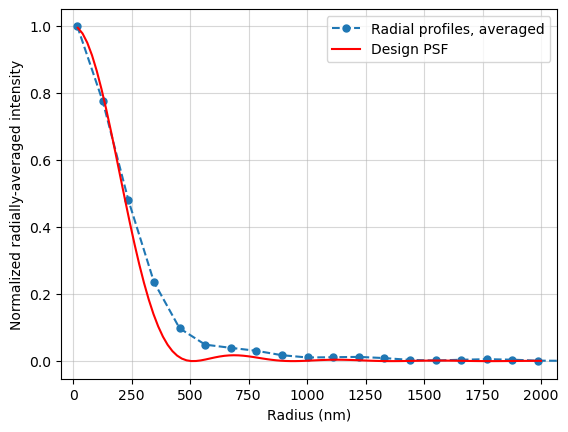

In [1766]:
# run multi-image analysis
dark = None
for dark_file in os.listdir(dark_folder):
    dark = np.array(Image.open(dark_folder + '/' + dark_file), dtype = 'int64')
dark = dark / len(os.listdir(dark_folder)) # get average dark shot
radius_data = np.array([])
image_data = np.array([])
for img_file in os.listdir(image_folder):
    im = np.array(Image.open(image_folder + '/' + img_file), dtype = 'int64')
    im = im - dark
    cropped = im[x_center_guess - int(roi_size/2):x_center_guess + int(roi_size/2), 
                 y_center_guess - int(roi_size/2):y_center_guess + int(roi_size/2)]
    # find center
    x_center, y_center = find_center(cropped, show_fit=False)
    # do radial average around centers
    r, data = radial_profile(cropped, 
                             [x_center, y_center], 
                             camera_magnification = camera_magnification, 
                             imaging_magnification = imaging_magnification)
    radius_data = np.append(radius_data, r)
    image_data = np.append(image_data, data)

# how sort, bin, and plot:
s = np.argsort(radius_data)
sorted_r = radius_data[s]
sorted_image_data = image_data[s]
r_binned_image_data, edges, _ = scipy.stats.binned_statistic(sorted_r, sorted_image_data, 'mean', bins=bins)
r_binned_image_data = r_binned_image_data/max(r_binned_image_data)
r_binned = edges[:-1]

plt.plot(r_binned, r_binned_image_data, '.--', markersize = 10, label = 'Radial profiles, averaged')

# generate design psf
r_psf = np.linspace(0, 2000, 100)
psf = ideal_psf(r_psf, NA = 0.7, lam = 589)

plt.plot(r_psf, psf, color = 'red', label = 'Design PSF')
plt.xlabel('Radius (nm)')
plt.ylabel('Normalized radially-averaged intensity')
plt.xlim([-50,2070])
plt.legend()
plt.grid(alpha = 0.5)
plt.show()


In [1788]:
# single-image analysis
image_filename = '1.tiff'
image_file = '/Users/huanbui/Desktop/microscope_testing/20250123/images/' + image_filename
dark_folder = '/Users/huanbui/Desktop/microscope_testing/20250123/dark_shots/'
camera_magnification = 6.45 # um per pixel
imaging_magnification = 51.7 # 51.7
bins = 30
# crop to get a smaller image to work faster
roi_size = 32
x_center_guess, y_center_guess = 385, 377 # 509, 511

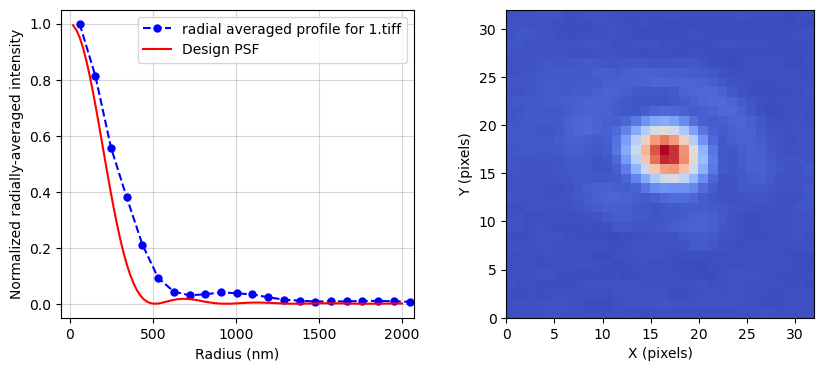

In [1791]:
# run single-image analysis
dark = None
for dark_file in os.listdir(dark_folder):
    dark = np.array(Image.open(dark_folder + dark_file), dtype = 'int64')
dark = dark / len(os.listdir(dark_folder)) # get average dark shot
im = np.array(Image.open(image_file), dtype = 'int64')
im = im - dark
cropped = im[x_center_guess - int(roi_size/2):x_center_guess + int(roi_size/2), 
                y_center_guess - int(roi_size/2):y_center_guess + int(roi_size/2)]
# find center
x_center, y_center = find_center(cropped, show_fit=False)
# do radial average around centers
r_binned, r_binned_data = radial_profile_with_binning(cropped, 
                                                      [x_center, y_center], 
                                                      bins = 30, 
                                                      camera_magnification = camera_magnification, 
                                                      imaging_magnification = imaging_magnification)
# generate design psf
r_psf = np.linspace(0, 2000, 100)
psf = ideal_psf(r_psf, NA = 0.7, lam = 589)
fig, ax = plt.subplots(nrows = 1, ncols=2, figsize = (10,4))
ax[0].plot(r_binned, r_binned_data, '.--', color = 'blue', markersize = 10, label = 'radial averaged profile for ' + image_filename)
ax[0].plot(r_psf, psf, color = 'red', label = 'Design PSF')
ax[0].set_xlabel('Radius (nm)')
ax[0].set_ylabel('Normalized radially-averaged intensity')
ax[0].set_xlim([-50,2070])
ax[0].legend()
ax[0].grid(alpha = 0.5)

ax[1].pcolor(cropped, cmap = 'coolwarm')
ax[1].set_xlabel('X (pixels)')
ax[1].set_ylabel('Y (pixels)')
ax[1].axis('square')
plt.show()

Quick note: Physical units for exit pupil and point spread functions. Numerically, the array dimensions of the exit pupil and the point spread function are preserved by Python's FFT. However, the "magnification" is different. To conversion from the magnification in the pupil plane to the image plane is given by:
$$ M_\text{psf} = \frac{\lambda f}{L} $$
where $f$ is the distance between the planes (or the focal length of the tube lens), $\lambda$ is the wavelength of light, and $L$ is the physical size of the pupil plane. The factor of $1/L$ is due to the Fourier transform. Can also see that the only way to increase the magnification of the PSF plane without changing physical aspects of the imaging system is to increase the size of the pupil plane. 

In [722]:
# wavefont expansion analysis:
pupil_plane_size_in_pixels = 256 # pixels
pupil_diam_in_mm = 53 # mm
pupil_plane_magnification = 6 * pupil_diam_in_mm / pupil_plane_size_in_pixels # mm per pixels
pupil_diam_in_pixels = int(pupil_diam_in_mm / pupil_plane_magnification)
lam = 589 # nm
camera_size = 64 # camera ROI in pixels
f = 2000 # mm, distance between pupil to camera
psf_plane_magnification = lam * 1e-3 * f / (pupil_plane_size_in_pixels * pupil_plane_magnification) # um per pixel
# zernike polynomials
Z_coefs = np.zeros(15)
Z_coefs[4] = 0.1
Z_coefs[12] = -0.1
[Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44] = Z_coefs

# Set up pixel space. Each plane has their own magnification
u = np.linspace(-pupil_plane_size_in_pixels/2, pupil_plane_size_in_pixels/2,pupil_plane_size_in_pixels)
v = np.linspace(-pupil_plane_size_in_pixels/2, pupil_plane_size_in_pixels/2,pupil_plane_size_in_pixels)
[U,V] = np.meshgrid(u,v)
     
# calculate pupil function
p = pupil([U,V], pupil_diam_in_pixels)
# calculate aberration function (phase shift)
abbe = aberration([U,V],pupil_diam_in_pixels,
                 Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)
# calculate the complex pupil function
complex_p = complex_pupil([U,V],pupil_diam_in_pixels,Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)
# calculate point spread function from complex pupil
PSF = psf_profile([U,V], 2, 0, 0, pupil_diam_in_pixels,Z00,Zm11,Z11,Zm22,Z02,Z22,Zm33,Zm13,Z13,Z33,Zm44,Zm24,Z04,Z24,Z44)

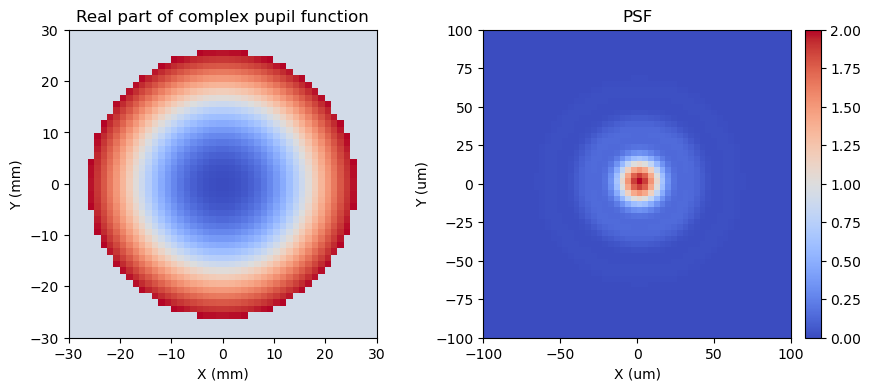

In [723]:
# plot aberration function and corresponding psf
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))
ax[0].pcolor(U * pupil_plane_magnification, V*pupil_plane_magnification, np.real(complex_p), cmap = 'coolwarm')
ax1 = ax[1].pcolor(U * psf_plane_magnification, V* psf_plane_magnification, PSF, cmap= 'coolwarm')
ax[0].axis('square')
ax[1].axis('square')
ax[0].set_xlim([-30,30])
ax[0].set_ylim([-30,30])
ax[1].set_xlim([-100,100])
ax[1].set_ylim([-100,100])
ax[0].set_xlabel('X (mm)')
ax[0].set_ylabel('Y (mm)')
ax[1].set_xlabel('X (um)')
ax[1].set_ylabel('Y (um)')
ax[1].set_title('PSF')
ax[0].set_title('Real part of complex pupil function')
fig.colorbar(ax1, fraction=0.046, pad=0.04, ax=ax[1])
plt.show()

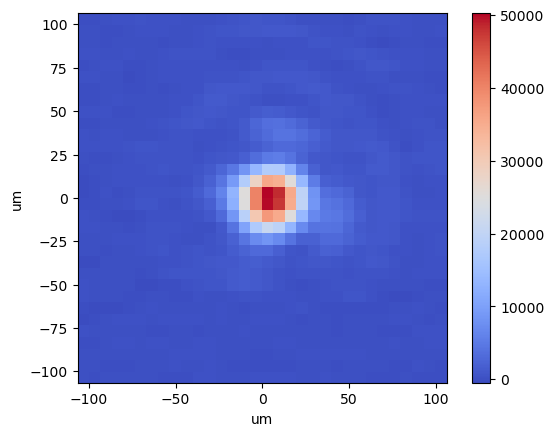

In [725]:
# re-crop so that feature is as centered as possible
centered_cropped = im[x_center_guess - int(x_center-roi_size/2) - int(roi_size/2) : x_center_guess - int(x_center-roi_size/2) + int(roi_size/2), 
                      y_center_guess - int(y_center-roi_size/2) - int(roi_size/2) : y_center_guess - int(y_center-roi_size/2) + int(roi_size/2)]
x_um = np.linspace(-roi_size/2, roi_size/2, roi_size) * camera_magnification
y_um = np.linspace(-roi_size/2, roi_size/2, roi_size) * camera_magnification
X_um, Y_um = np.meshgrid(x_um, y_um)
plt.pcolor(X_um, Y_um, centered_cropped, cmap = 'coolwarm')
plt.axis('square')
plt.xlabel('um')
plt.ylabel('um')
plt.colorbar()
plt.show()

In [735]:
# perform wavefront expansion to get zernike's coefs
def fit_zernike(v_um, data, pupil_diam_in_pixels):
    data = np.nan_to_num(data, nan = np.inf)
    X,Y = v_um
    # generate fit model with initial guesses
    model = Model(psf_profile)
    params = model.make_params(amplitude = np.max(data),
                               offset = 0,
                               theta = dict(value=0, min=0, max = 1),
                               pupil_diam_in_pixels = pupil_diam_in_pixels,
                               Z00 = dict(value=0, min=0, max = 1),
                               Zm11=0, Z11=0,
                               Zm22=0, Z02=0.1, Z22=0,
                               Zm33=0,Zm13=0,Z13=0,Z33=0,
                               Zm44=0,Zm24=0,Z04=0.0,Z24=0,Z44=0)
    params['pupil_diam_in_pixels'].vary = False
    # params['Z00'].vary = False
    # params['Zm11'].vary = False
    # params['Z11'].vary = False
    # params['Zm11'].vary = False
    # params['Zm22'].vary = False
    # params['Zm24'].vary = False
    # params['Zm44'].vary = False
    # params['Zm13'].vary = False
    # params['Zm33'].vary = False
    # params['Zm33'].vary = False
    # params['theta'].vary = 0 
    lmfit_result = model.fit(data, params, x= np.array((X, Y)), weights = None)
    # report = lmfit_result.fit_report()
    # print(report)

    # fitted data:
    data_fitted = psf_profile((X,Y),
                            amplitude = lmfit_result.params['amplitude'].value,
                            offset = lmfit_result.params['offset'].value,
                            theta = lmfit_result.params['theta'].value, 
                            pupil_diam_in_pixels = pupil_diam_in_pixels,
                            Z00  = lmfit_result.params['Z00'].value,
                            Zm11 = lmfit_result.params['Zm11'].value,
                            Z11  = lmfit_result.params['Z11'].value,
                            Zm22 = lmfit_result.params['Zm22'].value,
                            Z02  = lmfit_result.params['Z02'].value,
                            Z22  = lmfit_result.params['Z22'].value,
                            Zm33 = lmfit_result.params['Zm33'].value,
                            Zm13 = lmfit_result.params['Zm13'].value,
                            Z13  = lmfit_result.params['Z13'].value,
                            Z33  = lmfit_result.params['Z33'].value,
                            Zm44 = lmfit_result.params['Zm44'].value,
                            Zm24 = lmfit_result.params['Zm24'].value,
                            Z04  = lmfit_result.params['Z02'].value,
                            Z24  = lmfit_result.params['Z24'].value,
                            Z44  = lmfit_result.params['Z44'].value)
    data_fitted = data_fitted.reshape(data.shape[0],data.shape[1])
    return lmfit_result, data_fitted

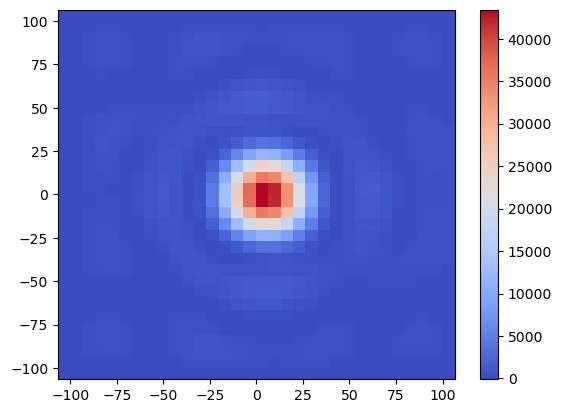

In [894]:
res, data_fitted = fit_zernike([X_um, Y_um], centered_cropped, pupil_diam_in_pixels)
plt.pcolor(X_um, Y_um, data_fitted, cmap = 'coolwarm')
plt.colorbar()
plt.show()

# <font size = 5>Deconvolution of quantum gas microscope images</font>

In [1154]:
# helper functions
def psf_2d(x, y, NA = 0.7, lam = 589):
    R = 0.61 * lam / NA # radius of first zero, lam in nm
    Rz = 1.2196698912665045
    u = np.pi * np.sqrt(x**2 + y**2) / (R/Rz) # r in nm
    return (2 * jn(1, u) / u)**2

def convolve_fluo_intensity_with_PSF(x_nm_lattice, y_nm_lattice, fluo_intensity, lattice_constant, NA, lam):
    unpixelated_image = np.zeros((len(x_nm_lattice), len(y_nm_lattice)))
    for ix in range(len(x_nm_lattice)):
        for iy in range(len(y_nm_lattice)):
            x_psf = x_nm_lattice[ix] - lattice_constant*(np.arange(0,fluo_intensity.shape[0]) - int(fluo_intensity.shape[0]/2)+1/2)
            y_psf = y_nm_lattice[iy] - lattice_constant*(np.arange(0,fluo_intensity.shape[1]) - int(fluo_intensity.shape[1]/2)+1/2)
            X_psf, Y_psf = np.meshgrid(x_psf, y_psf)
            psf = psf_2d(X_psf, Y_psf, NA = NA, lam = lam)
            unpixelated_image[iy][ix] = np.sum(np.multiply(fluo_intensity, psf)) 
    return unpixelated_image

def dark_BG(mu, sigma, size):
    return np.reshape(halfnorm.rvs(loc = mu, scale = sigma, size=size**2), (size, size) )

In [1840]:
# optical lattice and imaging parameters
lattice_constant = 532
NA = 0.7
lam = 589
imaging_magnification = 63 # 51.7
pixel_size = 13.0 # um per pixel
pixels_per_lattice_constant = imaging_magnification * lattice_constant * 1e-3 / pixel_size
effective_magnification = pixel_size/imaging_magnification
camera_pix_per_um = 1/effective_magnification # pixels per um in object plane
typ_fluo_level_per_site = 10000
diffraction_limit = 0.61 * lam / NA
lattice_size = 32 # in units of lattice constants
lattice_padding = 2 # in units of lattice constants, must be even
camera_ROI_size = int((lattice_size + lattice_padding) * lattice_constant / (effective_magnification*1000)) # pixels
filling_fraction = 0.20
psf_kernel_size = 5 # in units of lattice constants
pixels_per_site = 2*4 # for generating true image, must be even
# dark counts come from stray light/room light, follows half-normal distribution with offset muBG and width sigmaBG
muBG = 200 # counts per pixel of dark counts
sigmaBG = 3000 # but can be anything
detection_efficiency = 1

In [1841]:
# generate images
# initialize unpixelated image
lattice = np.random.choice([0, 1], size=(lattice_size, lattice_size), p=[1-filling_fraction, filling_fraction])
fluo_intensity = np.random.poisson(typ_fluo_level_per_site, size=(lattice_size, lattice_size)) * lattice

# convert into real-space lattice, with padding by 1 lattice site
x_nm_lattice = np.linspace(-(lattice_size + lattice_padding) * lattice_constant/2, 
                           (lattice_size + lattice_padding) * lattice_constant/2, 
                           (lattice_size + lattice_padding) * pixels_per_site)
y_nm_lattice = np.linspace(-(lattice_size + lattice_padding) * lattice_constant/2, 
                           (lattice_size + lattice_padding) * lattice_constant/2, 
                           (lattice_size + lattice_padding) * pixels_per_site)
X_nm, Y_nm = np.meshgrid(x_nm_lattice, y_nm_lattice)
real_space_lattice = np.zeros((len(x_nm_lattice), len(y_nm_lattice)))
real_space_lattice[int(pixels_per_site*(1/2 + lattice_padding//2)):-pixels_per_site*lattice_padding//2:pixels_per_site, 
                   int(pixels_per_site*(1/2 + lattice_padding//2)):-pixels_per_site*lattice_padding//2:pixels_per_site] = np.multiply(lattice, fluo_intensity)

# generate ideal pdf kernel for convolution: kernel size is 
x_nm_psf = np.linspace(-psf_kernel_size * lattice_constant/2, psf_kernel_size * lattice_constant/2, psf_kernel_size*pixels_per_site)
y_nm_psf = np.linspace(-psf_kernel_size * lattice_constant/2, psf_kernel_size * lattice_constant/2, psf_kernel_size*pixels_per_site)
X_nm_psf, Y_nm_psf = np.meshgrid(x_nm_psf, y_nm_psf)
psf = psf_2d(X_nm_psf, Y_nm_psf, NA=NA, lam=lam)
psf_pix_per_um = pixels_per_site / (lattice_constant * 1e-3)

# convolve this with the real image (no noise):
convolved_image = scipy.signal.convolve2d(real_space_lattice, psf, mode='same')

# pixelate to simulate camera image
dark_image = dark_BG(mu=muBG, sigma=sigmaBG, size=camera_ROI_size)
[X_camera, Y_camera] = np.meshgrid(np.arange(-camera_ROI_size/2, camera_ROI_size/2),np.arange(-camera_ROI_size/2, camera_ROI_size/2))
camera_image = np.array(Image.fromarray(convolved_image).resize(size=(camera_ROI_size, camera_ROI_size), resample= Image.NEAREST))
camera_image_with_noise = camera_image + dark_image

# calculate SNR by taking the mean fluo intensity over the occupied sites / background signal
snr = np.sum(fluo_intensity) / (np.sum(lattice) * sigmaBG)

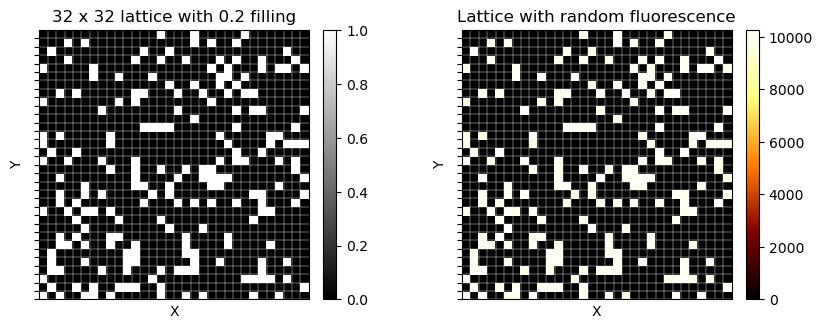

In [1842]:
# show lattice and lattice with peak fluorescence intensity
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 3.5))
ax0 = ax[0].pcolor(lattice, cmap='gray')
ax[0].axis('square')
ax[0].set_title(f'{lattice_size} x {lattice_size} lattice with {filling_fraction} filling')
ax[0].set_xticks(np.arange(0, lattice_size), ['']*lattice_size) 
ax[0].set_yticks(np.arange(0, lattice_size), ['']*lattice_size) 
ax[0].grid(color = 'white', linewidth = 0.3)
ax[0].tick_params(
    axis='x',          # changes apply to the x-axis
    bottom=False,      # ticks along the bottom edge are off
    labelbottom=False) # labels along the bottom edge are off
ax[0].tick_params(
    axis='y',          # changes apply to the x-axis
    bottom=False,      # ticks along the bottom edge are off
    labelbottom=False) # labels along the bottom edge are off
ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')
fig.colorbar(ax0, fraction=0.046, pad=0.04, ax=ax[0])
ax1 = ax[1].pcolor(fluo_intensity, cmap='afmhot')
ax[1].axis('square')
ax[1].set_title(f'Lattice with random fluorescence')
ax[1].set_xticks(np.arange(0, lattice_size), ['']*lattice_size) 
ax[1].set_yticks(np.arange(0, lattice_size), ['']*lattice_size) 
ax[1].grid(color = 'white', linewidth = 0.3)
ax[1].set_xlabel('X')
ax[1].set_ylabel('Y')
ax[1].tick_params(
    axis='x',          # changes apply to the x-axis
    bottom=False,      # ticks along the bottom edge are off
    labelbottom=False) # labels along the bottom edge are off
ax[1].tick_params(
    axis='y',          # changes apply to the x-axis
    bottom=False,      # ticks along the bottom edge are off
    labelbottom=False) # labels along the bottom edge are off
fig.colorbar(ax1, fraction=0.046, pad=0.04, ax=ax[1])
plt.show()

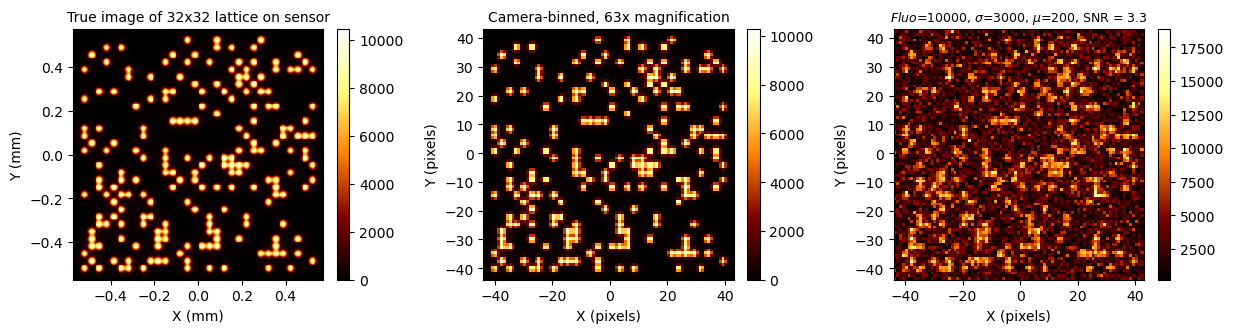

In [1843]:
# from camera pixelated image to point-like images again. 
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 3.25))
ax0 = ax[0].pcolor(x_nm_lattice*imaging_magnification/1e6, y_nm_lattice*imaging_magnification/1e6, convolved_image, cmap='afmhot') # gist_heat for K
ax[0].axis('square')
ax[0].set_title(f'True image of {lattice_size}x{lattice_size} lattice on sensor', fontsize = 10)
ax[0].set_xlabel('X (mm)')
ax[0].set_ylabel('Y (mm)')
fig.colorbar(ax0, fraction=0.046, pad=0.04, ax=ax[0])

ax1 = ax[1].pcolor(X_camera, Y_camera, camera_image, cmap='afmhot') # gist_heat for K
ax[1].axis('square')
ax[1].set_title(f'Camera-binned, {imaging_magnification}x magnification', fontsize = 10)
ax[1].set_xlabel('X (pixels)')
ax[1].set_ylabel('Y (pixels)')
fig.colorbar(ax1, fraction=0.046, pad=0.04, ax=ax[1])

ax2 = ax[2].pcolor(X_camera, Y_camera, camera_image_with_noise, cmap='afmhot') # gist_heat for K
ax[2].axis('square')
ax[2].set_title(f'$Fluo$={typ_fluo_level_per_site}, $\sigma$={sigmaBG}, $\mu$={muBG}, SNR = {snr:.1f}', fontsize = 9)
ax[2].set_xlabel('X (pixels)')
ax[2].set_ylabel('Y (pixels)')
fig.colorbar(ax2, fraction=0.046, pad=0.04, ax=ax[2])

plt.show()

In [2154]:
# Wiener deconvolution:
def wiener(camera_image, psf, K, camera_pix_per_um, psf_pix_per_um):
    # upscale image such that the psf and the camera image has the same "magnification"
    upscale_factor = psf_pix_per_um/camera_pix_per_um
    upscaled_camera_image = np.array(Image.fromarray(camera_image).resize(size=(round(camera_ROI_size*upscale_factor), 
                                                                                round(camera_ROI_size*upscale_factor)), 
                                                                        resample= Image.NEAREST))
    # treat cases where image/kernel sizes differ:
    # TODO: extend this to cover more cases
    if psf.shape[0] < upscaled_camera_image.shape[0]:
        diff0 = upscaled_camera_image.shape[0] - psf.shape[0]
        diff1 = upscaled_camera_image.shape[1] - psf.shape[1]
        top_pad = diff0//2
        bottom_pad = diff0 - top_pad
        right_pad = diff1//2
        left_pad = diff1 - right_pad
        psf = np.pad(psf, ((top_pad, bottom_pad), (right_pad, left_pad)), 'constant')

    F_psf = fft2(psf)
    FI = fft2(upscaled_camera_image)
    w = ifft2((FI/F_psf) * np.abs(F_psf)**2 / (np.abs(F_psf)**2 + K))    
    w = np.abs(ifftshift(w))

    # plt.pcolor(w, cmap = 'afmhot')
    # plt.colorbar()

    # get lattice spacing in pixels:
    cols = np.sum(w, axis = 0)
    rows = np.sum(w, axis = 1)
    fcols = np.abs(fft(cols))
    fcols[0:1] = 0 # set DC part to 0
    freqs = fftfreq(cols.shape[0])
    fcols = fcols[0:len(fcols)//2]
    freqs = freqs[0:len(freqs)//2]
    lattice_spacing_in_pix = round(1/freqs[ np.argmax(fcols)]) # 1/first harmonic

    # find the location of the first peak, then back out by lattice_spacing/2:
    col_peaks = scipy.signal.find_peaks(cols, height=np.mean(cols)) # first element is the first peak
    grid_start_col = col_peaks[0][0] - lattice_spacing_in_pix//2 - 1
    grid_end_col = ((w.shape[1] - grid_start_col)//lattice_spacing_in_pix) * lattice_spacing_in_pix + grid_start_col
    row_peaks = scipy.signal.find_peaks(rows, height=np.mean(rows)) # first element is the first peak
    grid_start_row = row_peaks[0][0] - lattice_spacing_in_pix//2 - 1
    grid_end_row = ((w.shape[0] - grid_start_row)//lattice_spacing_in_pix) * lattice_spacing_in_pix + grid_start_row

    # generate new image for which 
    w = w[grid_start_row:grid_end_row,grid_start_col:grid_end_col]

    # print(lattice_spacing_in_pix)
    # print(grid_start_col)
    # print(grid_end_col)
    # print(grid_start_row)
    # print(grid_end_row)

    return lattice_spacing_in_pix, w

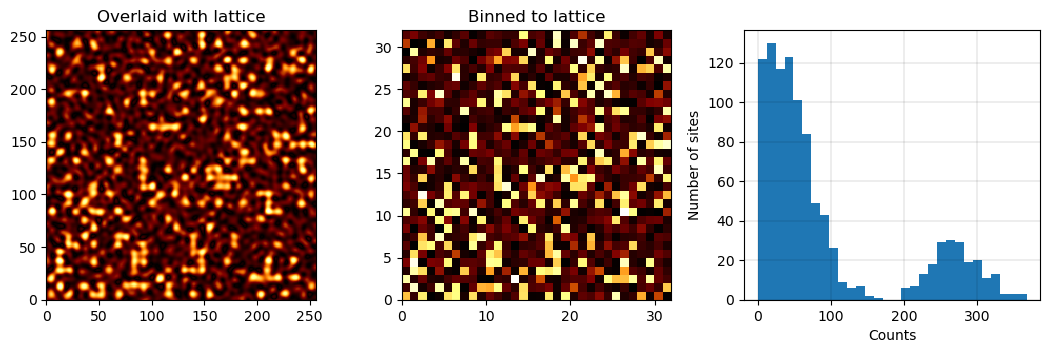

In [2155]:
# bin into boxes of size lattice_spacing_in_pix x lattice_spacing_in_pix
lattice_spacing_in_pix, w = wiener(camera_image_with_noise, psf, 250, camera_pix_per_um, psf_pix_per_um)
w_binned = np.array(Image.fromarray(w).resize(size=(w.shape[0]//lattice_spacing_in_pix, w.shape[1]//lattice_spacing_in_pix), resample= Image.NEAREST))
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (13,3.5))
ax[0].pcolor(w, cmap = 'afmhot')
ax[0].axis('square')
ax[0].set_title('Overlaid with lattice')
ax[1].pcolor(w_binned, cmap = 'afmhot')
ax[1].axis('square')
ax[1].set_title('Binned to lattice')
ax[2].hist(w_binned.ravel(), bins = 30)
ax[2].grid(color = 'black', linewidth = 0.1)
ax[2].set_xlabel('Counts')
ax[2].set_ylabel('Number of sites')
plt.show()